In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
benchmark_df = pd.read_csv(r'./uniprot_dataset/benchmark_df.csv')
reproduced_df = pd.read_csv(r'./uniprot_dataset/reproduced_df.csv')

In [3]:
print(len(benchmark_df))
print(len(reproduced_df))

72731
72302


In [4]:
merge_entries = benchmark_df.rename(
    columns={'uniprot_id': 'seq_id', 'aa_change': 'mut_name'}
).merge(
    reproduced_df, on=['seq_id', 'mut_name'], how='left', indicator=True
)
missing_entries = merge_entries[merge_entries['_merge'] == 'left_only'].drop(columns=['_merge'])

print(f"Missing (seq_id, mut_name) pairs in reproduced_df: {len(missing_entries)}")
print(missing_entries.head())

unique_missing_seq_ids = missing_entries[['seq_id']].drop_duplicates()
print(f"Unique missing seq_id values in reproduced_df: {len(unique_missing_seq_ids)}")
print(unique_missing_seq_ids['seq_id'].tolist())

Missing (seq_id, mut_name) pairs in reproduced_df: 429
     seq_id mut_name  ESM1b_score  esm_score
913  O00255    C426Y      -11.601        NaN
914  O00255    S432R       -8.308        NaN
915  O00255    W441C      -14.733        NaN
916  O00255    D423Y      -14.932        NaN
917  O00255    D423H      -12.866        NaN
Unique missing seq_id values in reproduced_df: 111
['O00255', 'O75319', 'O75747', 'O76011', 'O76036', 'O95755', 'P01019', 'P02708', 'P06731', 'P07686', 'P0C6A0', 'P11182', 'P18887', 'P20929', 'P21675', 'P23109', 'P29973', 'P33261', 'P43026', 'P49842', 'P51587', 'P54296', 'P57071', 'P59826', 'P59901', 'P60370', 'P60371', 'Q03518', 'Q08AF8', 'Q0D2K0', 'Q14002', 'Q14241', 'Q2M2W7', 'Q3KPI0', 'Q3LFD5', 'Q3MIN7', 'Q5T890', 'Q5TI25', 'Q5VWP3', 'Q6GMV1', 'Q6GTX8', 'Q6IFG1', 'Q6NSX1', 'Q6P4F2', 'Q6P587', 'Q6RUI8', 'Q6SJ96', 'Q6URK8', 'Q6ZRC1', 'Q6ZVW7', 'Q7RTR8', 'Q7Z4U5', 'Q8IV35', 'Q8IXP5', 'Q8N5Z5', 'Q8N8F6', 'Q8N957', 'Q8NBV8', 'Q8NFD5', 'Q8NFV4', 'Q8NGC3', 'Q8NGH7', 'Q8

In [5]:
benchmark_df = merge_entries[merge_entries['_merge'] == 'both'][['seq_id', 'mut_name', 'ESM1b_score']]
benchmark_df.head()

,seq_id,mut_name,ESM1b_score
0,A0AUZ9,N660S,-3.064
1,A0AV02,R664Q,-7.572
2,A0AV02,K342R,-5.013
3,A0AV02,R181C,-10.698
4,A0AV02,K541R,-2.938


In [6]:
benchmark_score = benchmark_df['ESM1b_score'].values
reproduced_score = reproduced_df['esm_score'].values

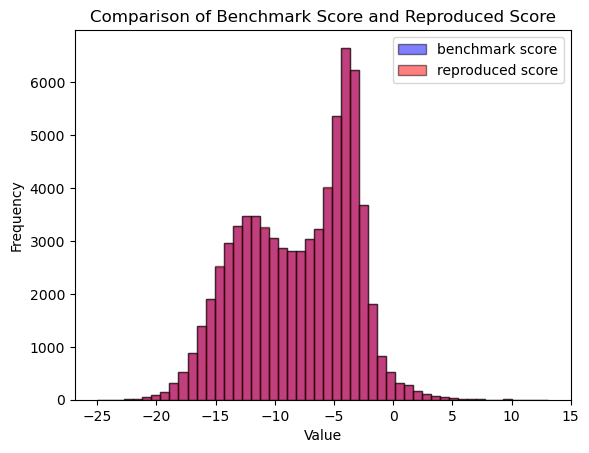

In [7]:
plt.hist(benchmark_score, bins=50, alpha=0.5, label='benchmark score', color='blue', edgecolor='black')
plt.hist(reproduced_score, bins=50, alpha=0.5, label='reproduced score', color='red', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Comparison of Benchmark Score and Reproduced Score')

plt.legend()
plt.savefig(r'./uniprot_dataset/benchmark_reproduce_comparison.jpg')

plt.show()

RMS of differences: 0.11335131703553794
indices of mutations with diff > 5: {921: {'seq_id': 'O00255', 'mut_name': 'H139R'}, 923: {'seq_id': 'O00255', 'mut_name': 'H139Q'}, 924: {'seq_id': 'O00255', 'mut_name': 'H139D'}, 9590: {'seq_id': 'P01106', 'mut_name': 'P72S'}, 15176: {'seq_id': 'P08519', 'mut_name': 'R2016C'}, 22051: {'seq_id': 'P23109', 'mut_name': 'K320I'}, 35948: {'seq_id': 'Q01433', 'mut_name': 'R324P'}, 40036: {'seq_id': 'Q13507', 'mut_name': 'R762H'}, 48607: {'seq_id': 'Q6ZVW7', 'mut_name': 'C299Y'}, 61739: {'seq_id': 'Q9BRI3', 'mut_name': 'G87R'}, 65245: {'seq_id': 'Q9HBL0', 'mut_name': 'V25I'}, 71095: {'seq_id': 'Q9Y2K3', 'mut_name': 'M1798V'}}


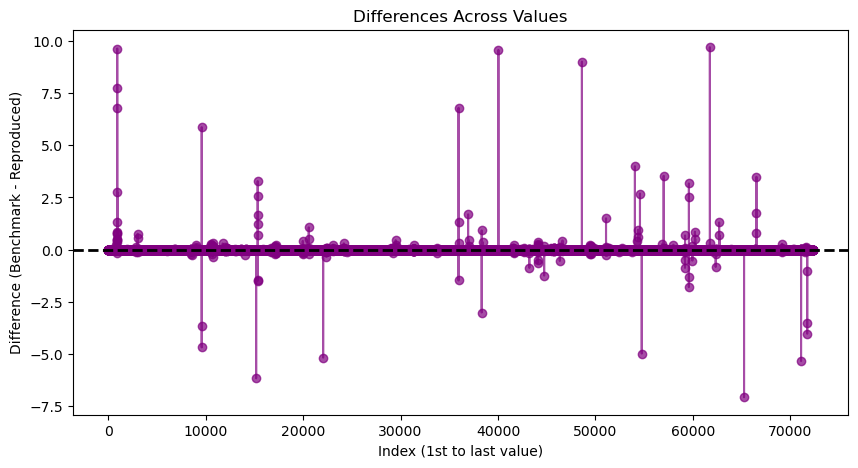

In [22]:
differences = np.array(benchmark_score) - np.array(reproduced_score)

rms = np.sqrt(np.mean(differences**2))
print(f"RMS of differences: {rms}")

significant_indices = np.where(abs(differences) > 5)[0].tolist()
significant_names = reproduced_df.iloc[significant_indices][['seq_id', 'mut_name']].to_dict(orient='records')
significant_annotations = dict(zip(significant_indices, significant_names))
print(f'indices of mutations with diff > 5: {significant_annotations}')

plt.figure(figsize=(10, 5))

plt.plot(differences, marker='o', linestyle='-', color='purple', alpha=0.7)

plt.axhline(0, color='black', linestyle='dashed', linewidth=2)

plt.xlabel('Index (1st to last value)')
plt.ylabel('Difference (Benchmark - Reproduced)')
plt.title('Differences Across Values')

plt.savefig(r'./uniprot_dataset/difference_plot.jpg')
plt.show()